# Superfluid weight of superconductors and its quantum geometry
A finite pairing amplitude does not by itself make a superconductor: what carries the
supercurrent is the rigidity of the state against winding the phase of the order parameter,
the superfluid weight

$$
D_s^{ab} = \frac{1}{V}\frac{\partial^2 \Omega}{\partial Q_a \partial Q_b}
$$

the second derivative of the grand potential with respect to the twist wavevector $\mathbf Q$
of the phase, at fixed $|\Delta|$. `h.get_superfluid_weight()` computes it for a BdG
Hamiltonian, and with `decompose=True` splits it into a *conventional* part, coming from the
band velocities, and a *quantum-geometric* part, coming from interband matrix elements. For an
isolated flat band the geometric part reduces to the integral of the quantum metric: a flat
band has no velocity, so all of its stiffness is geometric, which is why flat-band
superconductivity is possible at all. In two dimensions `h.get_bkt_temperature()` then gives the
Berezinskii-Kosterlitz-Thouless temperature from the Nelson-Kosterlitz criterion
$T_{\rm BKT} = (\pi/8) D_s(T_{\rm BKT})$, at frozen $|\Delta|$.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### A single band: all the stiffness is conventional
Let us start with the square lattice away from half filling. A single-band model has no other
band to have matrix elements with, so the geometric part vanishes and the whole superfluid
weight comes from the band velocity.

In [2]:
g = geometry.square_lattice() # geometry of the 2D model
h = g.get_hamiltonian() # first-neighbor hopping
h.add_onsite(-0.6) # move away from half filling
h.add_swave(0.3) # BdG Hamiltonian with an s-wave gap

out = h.get_superfluid_weight(nk=20,decompose=True)
print("D_s^xx total        =",out["total"][0,0])
print("D_s^xx conventional =",out["conventional"][0,0])
print("D_s^xx geometric    =",out["geometric"][0,0])
print("T_BKT               =",h.get_bkt_temperature(nk=20)) # Nelson-Kosterlitz

D_s^xx total        = 0.7610733972594865
D_s^xx conventional = 0.7610733972594865
D_s^xx geometric    = 0.0


T_BKT               = 0.14950752642497636


### The flat band of the kagome lattice
The kagome lattice has three bands, one of them flat, at $E=-2$ in units of the hopping, touching
the lower dispersive band at the center of the Brillouin zone. We now sweep the chemical
potential $\mu$ through the flat band and the dispersive band above it, and the gap $\Delta$,
and map over that plane the total $D_s^{xx}$ and the fraction of it that is geometric. In the
dispersive band the stiffness is large, set by the Fermi velocity, barely depends on $\Delta$ and
is mostly conventional; with the chemical potential in the flat band the stiffness is small,
grows with $\Delta$, and most of it is geometric, which is the signature of flat-band
superconductivity.

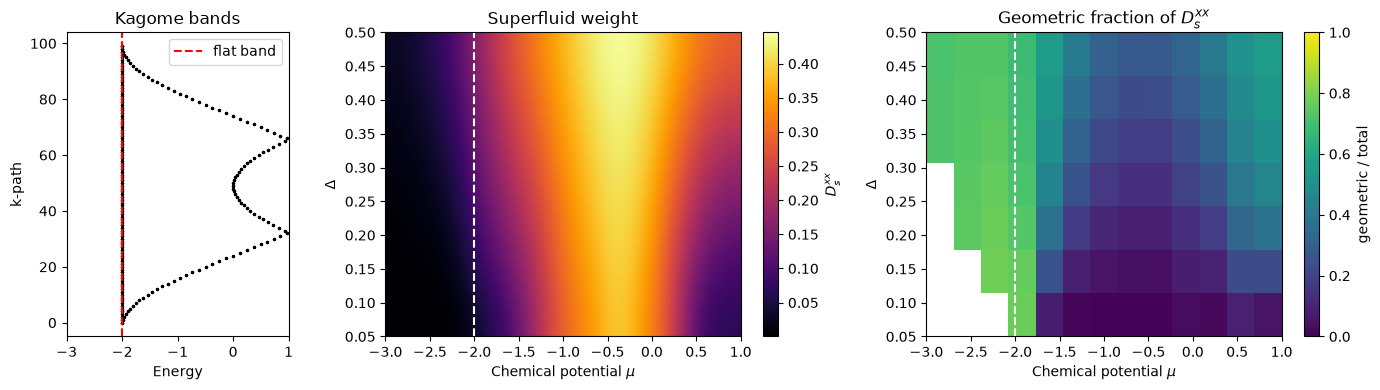

In [3]:
g = geometry.kagome_lattice() # three sites per unit cell
h0 = g.get_hamiltonian() # first-neighbor hopping
(k,e) = h0.get_bands(nk=100) # normal-state band structure

mus = np.linspace(-3.,1.,13) # chemical potentials
deltas = np.linspace(0.05,0.5,7) # s-wave gaps
Dt = np.zeros((len(deltas),len(mus))) # total superfluid weight
Dg = np.zeros((len(deltas),len(mus))) # geometric part
for i,delta in enumerate(deltas):
    for j,mu in enumerate(mus):
        h = h0.copy()
        h.add_onsite(-mu) # put the chemical potential at mu
        h.add_swave(delta) # s-wave pairing
        out = h.get_superfluid_weight(nk=10,decompose=True)
        Dt[i,j] = out["total"][0,0]
        Dg[i,j] = out["geometric"][0,0]
fraction = np.where(Dt>1e-2,Dg/Dt,np.nan) # geometric fraction, blank in the gap

fig,axs = plt.subplots(1,3,figsize=(14,4),gridspec_kw={"width_ratios":[1,2,2]})
axs[0].scatter(e,k,s=2,c="black") # bands, energy on the horizontal axis
axs[0].axvline(-2.,c="red",ls="--",label="flat band")
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel("k-path")
axs[0].set_xlim([mus[0],mus[-1]]) ; axs[0].legend()
axs[0].set_title("Kagome bands")
extent = [mus[0],mus[-1],deltas[0],deltas[-1]]
im = axs[1].imshow(Dt,origin="lower",aspect="auto",extent=extent,
                   cmap="inferno",interpolation="bicubic")
plt.colorbar(im,ax=axs[1],label="$D_s^{xx}$")
axs[1].set_title("Superfluid weight")
im = axs[2].imshow(fraction,origin="lower",aspect="auto",extent=extent,
                   cmap="viridis",vmin=0.,vmax=1.)
plt.colorbar(im,ax=axs[2],label="geometric / total")
axs[2].set_title("Geometric fraction of $D_s^{xx}$")
for ax in axs[1:]:
    ax.axvline(-2.,c="white",ls="--")
    ax.set_xlabel("Chemical potential $\\mu$") ; ax.set_ylabel("$\\Delta$")
plt.tight_layout()
plt.show()

### BKT temperature in the flat band and in a dispersive band
With the chemical potential in the flat band the superfluid weight, and with it $T_{\rm BKT}$,
is set by the quantum geometry; in a dispersive band it is set by the Fermi velocity. The
temperature is an upper estimate, since $|\Delta|$ is kept frozen rather than solved at each
temperature.

In [4]:
for (mu,name) in [(-2.,"flat band"),(0.,"dispersive band")]:
    h = h0.copy()
    h.add_onsite(-mu) # chemical potential
    h.add_swave(0.3) # s-wave pairing
    print(name,": T_BKT =",h.get_bkt_temperature(nk=10))

flat band : T_BKT = 0.05295502493901563


dispersive band : T_BKT = 0.10974368521498096
